In [6]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    RandomizedSearchCV,
    cross_val_predict
)

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    mean_absolute_error,
    r2_score
)

from sklearn.inspection import permutation_importance

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

print("Libraries imported successfully!")

Libraries imported successfully!


In [7]:
from google.colab import files

uploaded = files.upload()

Saving diabetes_screening_data - diabetes_screening_data.csv to diabetes_screening_data - diabetes_screening_data (1).csv


In [8]:
df = pd.read_csv("diabetes_screening_data - diabetes_screening_data.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [9]:
print("DATASET INFORMATION")
print("===================")

df.info()

print("\n\nSTATISTICAL SUMMARY")
print("===================")

display(df.describe())

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


STATISTICAL SUMMARY


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [10]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [11]:
problematic_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

for col in problematic_columns:
    zero_count = (df[col] == 0).sum()
    zero_percent = (df[col] == 0).mean() * 100

    print(f"{col}:")
    print(f"  Zero values: {zero_count}")
    print(f"  Percentage: {zero_percent:.2f}%")
    print()

Glucose:
  Zero values: 5
  Percentage: 0.65%

BloodPressure:
  Zero values: 35
  Percentage: 4.56%

SkinThickness:
  Zero values: 227
  Percentage: 29.56%

Insulin:
  Zero values: 374
  Percentage: 48.70%

BMI:
  Zero values: 11
  Percentage: 1.43%



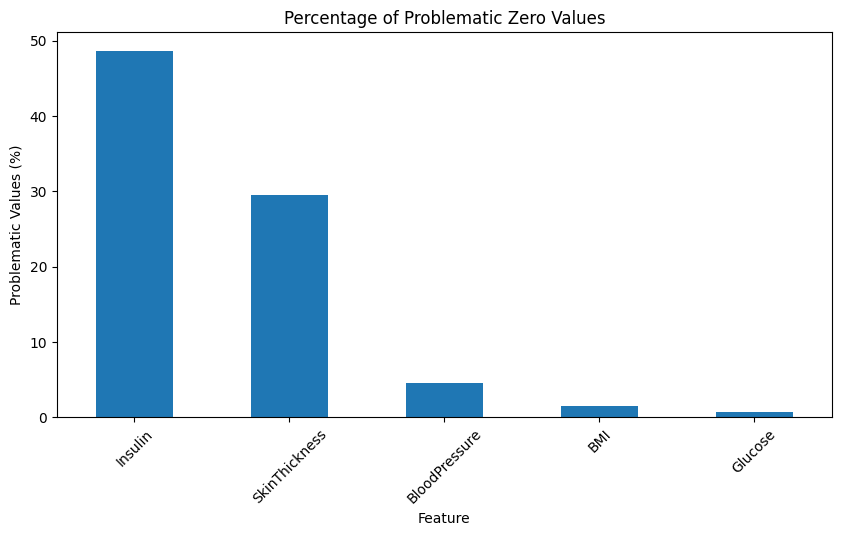

In [12]:
problem_percent = {}

for col in problematic_columns:
    problem_percent[col] = (df[col] == 0).mean() * 100

problem_percent = pd.Series(problem_percent)

plt.figure(figsize=(10, 5))

problem_percent.sort_values(ascending=False).plot(kind="bar")

plt.title("Percentage of Problematic Zero Values")
plt.xlabel("Feature")
plt.ylabel("Problematic Values (%)")
plt.xticks(rotation=45)

plt.show()

In [13]:
print("Outcome Counts")
print("================")

print(df["Outcome"].value_counts())

print("\nOutcome Percentages")
print("===================")

print((df["Outcome"].value_counts(normalize=True) * 100).round(2))

Outcome Counts
Outcome
0    500
1    268
Name: count, dtype: int64

Outcome Percentages
Outcome
0    65.1
1    34.9
Name: proportion, dtype: float64


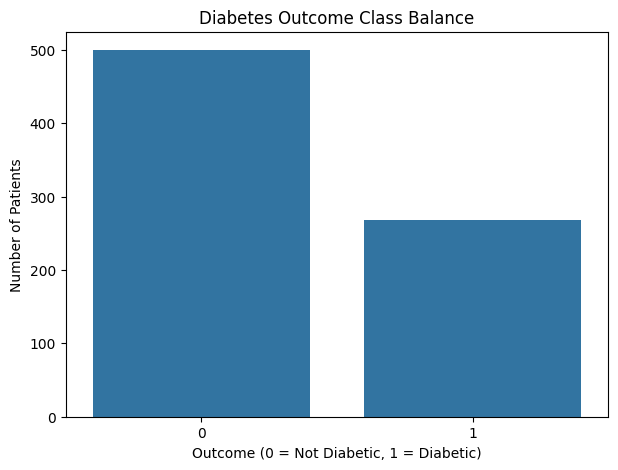

In [14]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Outcome")

plt.title("Diabetes Outcome Class Balance")
plt.xlabel("Outcome (0 = Not Diabetic, 1 = Diabetic)")
plt.ylabel("Number of Patients")

plt.show()

In [15]:
correlation = df.corr(numeric_only=True)

display(correlation["Outcome"].sort_values(ascending=False))

,Outcome
Outcome,1.000000
Glucose,0.466581
BMI,0.292695
Age,0.238356
Pregnancies,0.221898
DiabetesPedigreeFunction,0.173844
Insulin,0.130548
SkinThickness,0.074752
BloodPressure,0.065068


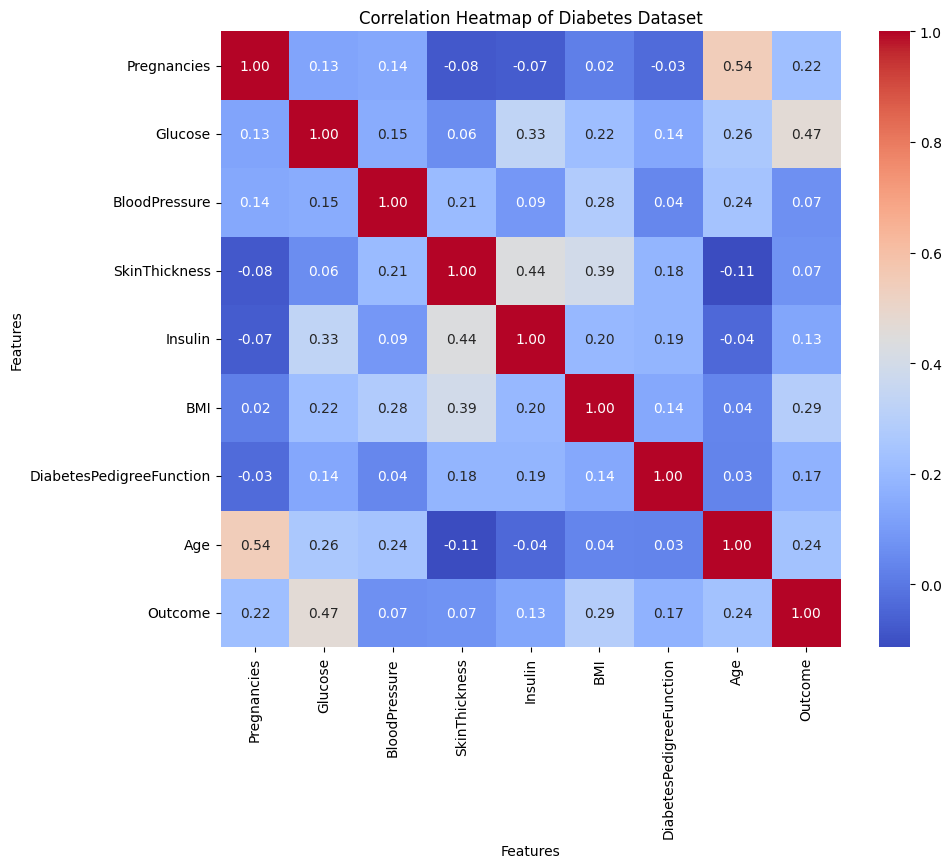

In [16]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Diabetes Dataset")
plt.xlabel("Features")
plt.ylabel("Features")

plt.show()

In [17]:
eda_df = df.copy()

for col in problematic_columns:
    eda_df[col] = eda_df[col].replace(0, np.nan)

print("EDA dataset prepared.")
print("Original dataset shape:", df.shape)
print("EDA dataset shape:", eda_df.shape)

EDA dataset prepared.
Original dataset shape: (768, 9)
EDA dataset shape: (768, 9)


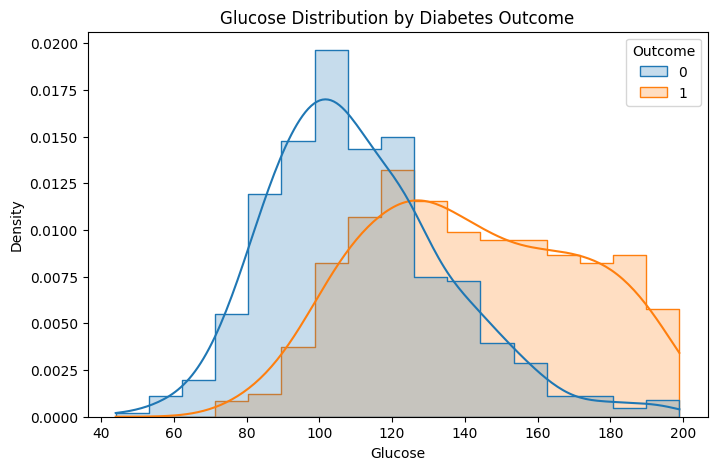

In [18]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=eda_df,
    x="Glucose",
    hue="Outcome",
    kde=True,
    element="step",
    stat="density",
    common_norm=False
)

plt.title("Glucose Distribution by Diabetes Outcome")
plt.xlabel("Glucose")
plt.ylabel("Density")

plt.show()

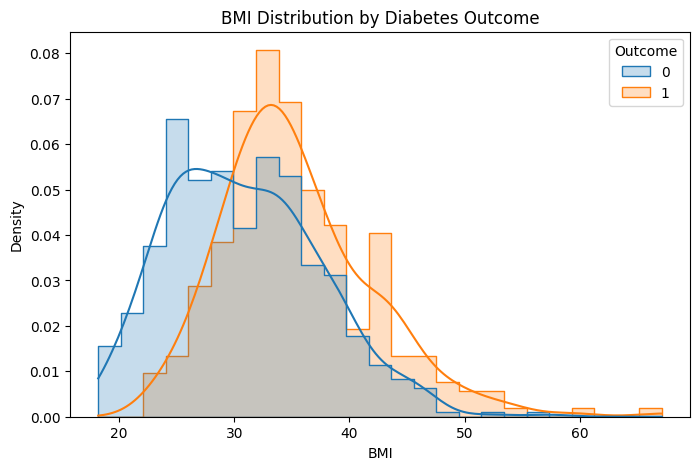

In [19]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=eda_df,
    x="BMI",
    hue="Outcome",
    kde=True,
    element="step",
    stat="density",
    common_norm=False
)

plt.title("BMI Distribution by Diabetes Outcome")
plt.xlabel("BMI")
plt.ylabel("Density")

plt.show()

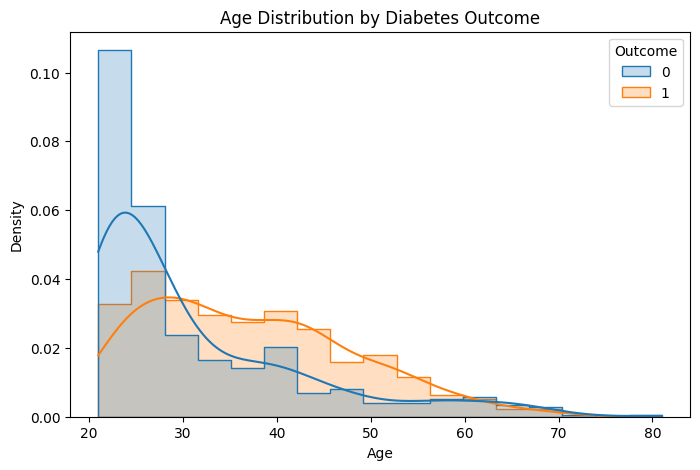

In [20]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=eda_df,
    x="Age",
    hue="Outcome",
    kde=True,
    element="step",
    stat="density",
    common_norm=False
)

plt.title("Age Distribution by Diabetes Outcome")
plt.xlabel("Age")
plt.ylabel("Density")

plt.show()

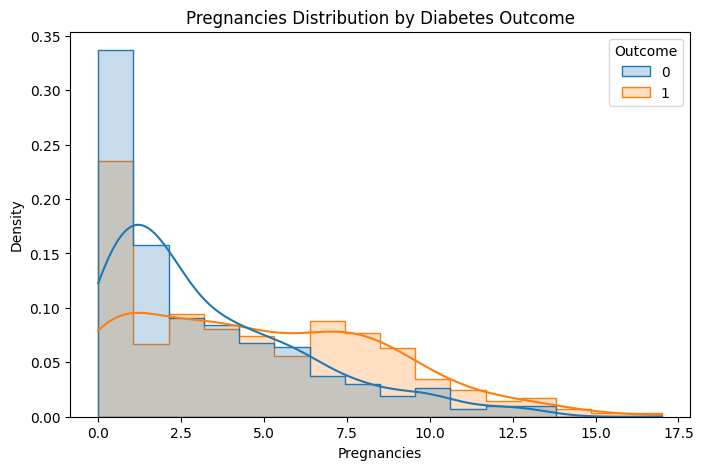

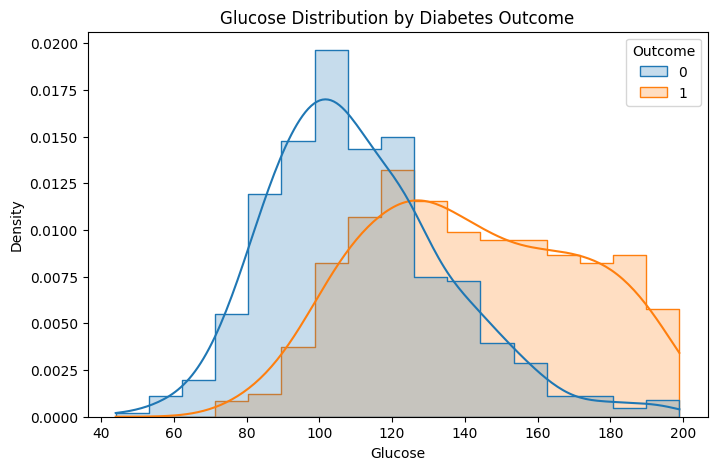

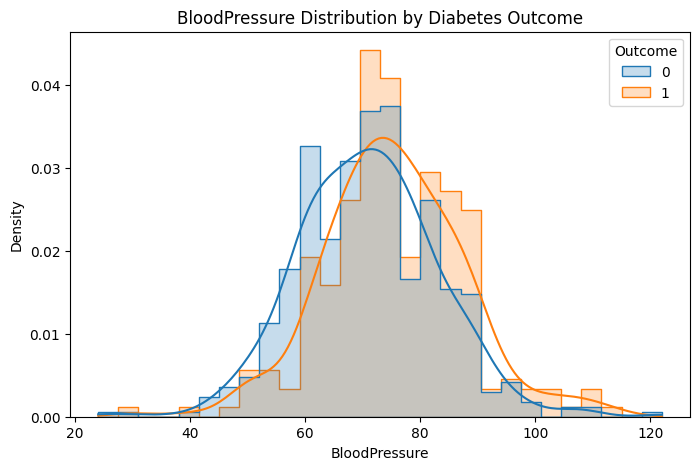

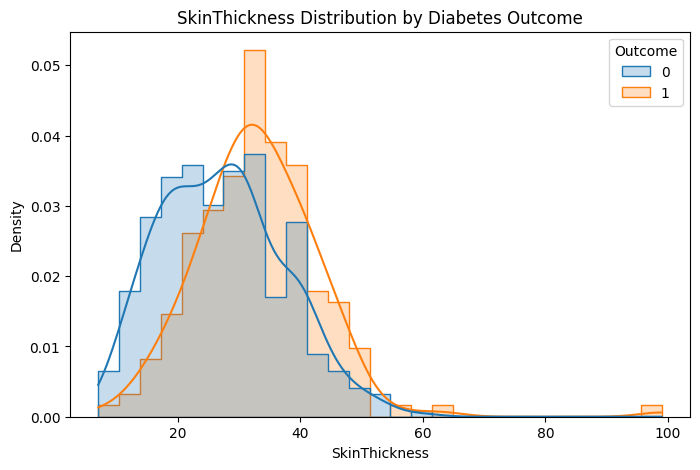

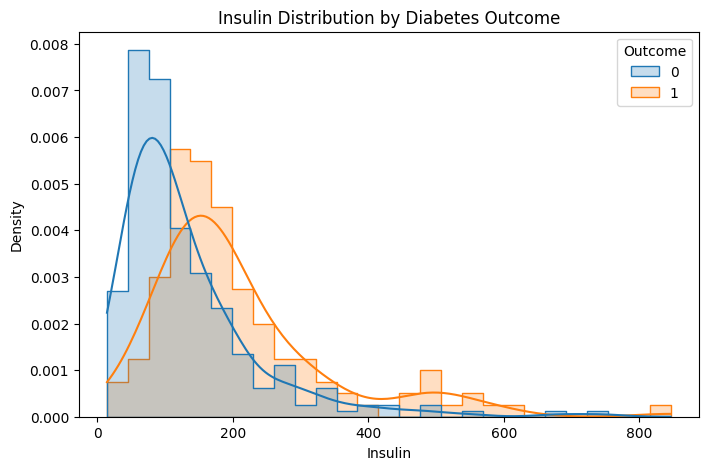

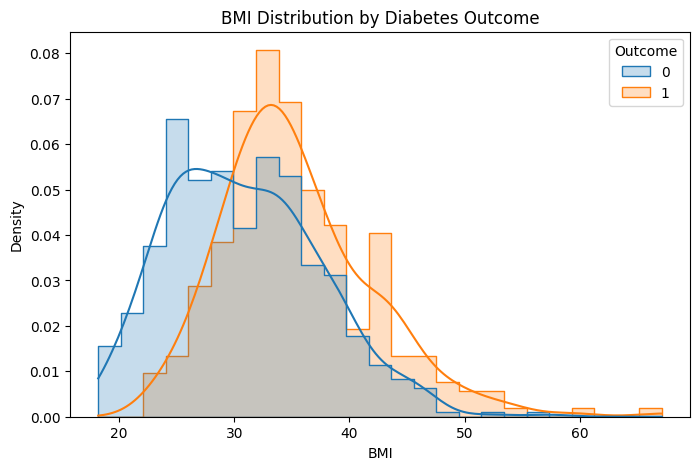

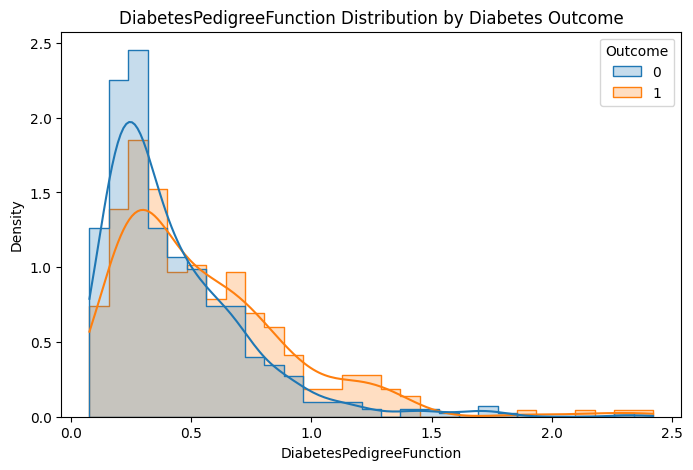

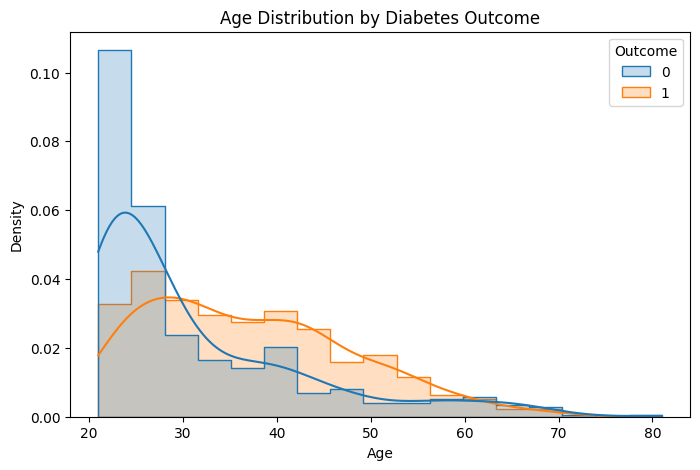

In [21]:
features = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]

for col in features:
    plt.figure(figsize=(8, 5))

    sns.histplot(
        data=eda_df,
        x=col,
        hue="Outcome",
        kde=True,
        element="step",
        stat="density",
        common_norm=False
    )

    plt.title(f"{col} Distribution by Diabetes Outcome")
    plt.xlabel(col)
    plt.ylabel("Density")

    plt.show()

In [22]:
features = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]

mean_comparison = df.groupby("Outcome")[features].mean().T

display(mean_comparison.round(2))

Outcome,0,1
Pregnancies,3.30,4.87
Glucose,109.98,141.26
BloodPressure,68.18,70.82
SkinThickness,19.66,22.16
Insulin,68.79,100.34
BMI,30.30,35.14
DiabetesPedigreeFunction,0.43,0.55
Age,31.19,37.07


## EDA Observations

1. Glucose is the feature most strongly associated with the diabetes outcome. Its correlation with Outcome is approximately 0.47, and the average glucose level is higher for Outcome = 1 patients (141.26) than for Outcome = 0 patients (109.98).

2. BMI also shows a positive relationship with diabetes outcome. The average BMI is 35.14 for Outcome = 1 patients compared with 30.30 for Outcome = 0 patients.

3. Age shows a positive association with diabetes outcome. The average age is higher for Outcome = 1 patients (37.07) than for Outcome = 0 patients (31.19).

4. Pregnancies also shows a positive relationship with the target. The average number of pregnancies is 4.87 for Outcome = 1 compared with 3.30 for Outcome = 0.

5. BloodPressure and SkinThickness have relatively weak correlations with Outcome (approximately 0.07 each), suggesting that their individual linear relationships with the target are weaker than those of Glucose, BMI, and Age.

In [23]:
df["ObesityFlag"] = (df["BMI"] >= 30).astype(int)

print("ObesityFlag created successfully!")
print(df[["BMI", "ObesityFlag"]].head(10))

ObesityFlag created successfully!
    BMI  ObesityFlag
0  33.6            1
1  26.6            0
2  23.3            0
3  28.1            0
4  43.1            1
5  25.6            0
6  31.0            1
7  35.3            1
8  30.5            1
9   0.0            0


In [24]:
df["HighGlucoseFlag"] = (df["Glucose"] >= 140).astype(int)

print("HighGlucoseFlag created successfully!")
print(df[["Glucose", "HighGlucoseFlag"]].head(10))

HighGlucoseFlag created successfully!
   Glucose  HighGlucoseFlag
0      148                1
1       85                0
2      183                1
3       89                0
4      137                0
5      116                0
6       78                0
7      115                0
8      197                1
9      125                0


In [25]:
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 30, 45, 60, 100],
    labels=["Young", "Adult", "Middle_Age", "Senior"]
)

print("AgeGroup created successfully!")
print(df[["Age", "AgeGroup"]].head(10))

AgeGroup created successfully!
   Age    AgeGroup
0   50  Middle_Age
1   31       Adult
2   32       Adult
3   21       Young
4   33       Adult
5   30       Young
6   26       Young
7   29       Young
8   53  Middle_Age
9   54  Middle_Age


In [26]:
df["BMI_Category"] = pd.cut(
    df["BMI"],
    bins=[0, 18.5, 25, 30, 100],
    labels=["Underweight", "Normal", "Overweight", "Obese"]
)

print("BMI_Category created successfully!")
print(df[["BMI", "BMI_Category"]].head(10))

BMI_Category created successfully!
    BMI BMI_Category
0  33.6        Obese
1  26.6   Overweight
2  23.3       Normal
3  28.1   Overweight
4  43.1        Obese
5  25.6   Overweight
6  31.0        Obese
7  35.3        Obese
8  30.5        Obese
9   0.0          NaN


In [27]:
df["GlucoseCategory"] = pd.cut(
    df["Glucose"],
    bins=[0, 100, 126, 200],
    labels=["Normal", "Prediabetes", "High"]
)

print("GlucoseCategory created successfully!")
print(df[["Glucose", "GlucoseCategory"]].head(10))

GlucoseCategory created successfully!
   Glucose GlucoseCategory
0      148            High
1       85          Normal
2      183            High
3       89          Normal
4      137            High
5      116     Prediabetes
6       78          Normal
7      115     Prediabetes
8      197            High
9      125     Prediabetes


In [28]:
print("New features created:")
print(df[["ObesityFlag", "HighGlucoseFlag", "AgeGroup",
          "BMI_Category", "GlucoseCategory"]].head(10))

New features created:
   ObesityFlag  HighGlucoseFlag    AgeGroup BMI_Category GlucoseCategory
0            1                1  Middle_Age        Obese            High
1            0                0       Adult   Overweight          Normal
2            0                1       Adult       Normal            High
3            0                0       Young   Overweight          Normal
4            1                0       Adult        Obese            High
5            0                0       Young   Overweight     Prediabetes
6            1                0       Young        Obese          Normal
7            1                0       Young        Obese     Prediabetes
8            1                1  Middle_Age        Obese            High
9            0                0  Middle_Age          NaN     Prediabetes


In [29]:
print("Missing values after feature engineering:")
print(df.isnull().sum())

Missing values after feature engineering:
Pregnancies                  0
Glucose                      0
BloodPressure                0
SkinThickness                0
Insulin                      0
BMI                          0
DiabetesPedigreeFunction     0
Age                          0
Outcome                      0
ObesityFlag                  0
HighGlucoseFlag              0
AgeGroup                     0
BMI_Category                11
GlucoseCategory              5
dtype: int64


In [30]:
problematic_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

for col in problematic_columns:
    df[col] = df[col].replace(0, np.nan)

print("Problematic zero values replaced with NaN!")
print(df[problematic_columns].isnull().sum())

Problematic zero values replaced with NaN!
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [31]:
for col in problematic_columns:
    df[col] = df[col].fillna(df[col].median())

print("Missing values handled successfully!")
print(df[problematic_columns].isnull().sum())

Missing values handled successfully!
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


In [32]:
print("Final Dataset Information")
print("=========================")

print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Final Dataset Information
Dataset Shape: (768, 14)

Missing Values:
Pregnancies                  0
Glucose                      0
BloodPressure                0
SkinThickness                0
Insulin                      0
BMI                          0
DiabetesPedigreeFunction     0
Age                          0
Outcome                      0
ObesityFlag                  0
HighGlucoseFlag              0
AgeGroup                     0
BMI_Category                11
GlucoseCategory              5
dtype: int64

Duplicate Rows: 0


In [33]:
print("Final Dataset Information")
print("=========================")

print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Final Dataset Information
Dataset Shape: (768, 14)

Missing Values:
Pregnancies                  0
Glucose                      0
BloodPressure                0
SkinThickness                0
Insulin                      0
BMI                          0
DiabetesPedigreeFunction     0
Age                          0
Outcome                      0
ObesityFlag                  0
HighGlucoseFlag              0
AgeGroup                     0
BMI_Category                11
GlucoseCategory              5
dtype: int64

Duplicate Rows: 0


In [34]:
# Recreate BMI and Glucose categories after missing values are handled

df["BMI_Category"] = pd.cut(
    df["BMI"],
    bins=[0, 18.5, 25, 30, 100],
    labels=["Underweight", "Normal", "Overweight", "Obese"]
)

df["GlucoseCategory"] = pd.cut(
    df["Glucose"],
    bins=[0, 100, 126, 200],
    labels=["Normal", "Prediabetes", "High"]
)

print("Categories recreated successfully!")

print("\nMissing values:")
print(df[["BMI_Category", "GlucoseCategory"]].isnull().sum())

Categories recreated successfully!

Missing values:
BMI_Category       0
GlucoseCategory    0
dtype: int64


In [35]:
print("FINAL DATASET CHECK")
print("===================")

print("Dataset Shape:", df.shape)

print("\nTotal Missing Values:", df.isnull().sum().sum())

print("Total Duplicate Rows:", df.duplicated().sum())

print("\nColumns:")
print(df.columns.tolist())

FINAL DATASET CHECK
Dataset Shape: (768, 14)

Total Missing Values: 0
Total Duplicate Rows: 0

Columns:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome', 'ObesityFlag', 'HighGlucoseFlag', 'AgeGroup', 'BMI_Category', 'GlucoseCategory']


In [36]:
# Separate features and target

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

print("\nTarget values:")
print(y.value_counts())

Features (X) shape: (768, 13)
Target (y) shape: (768,)

Target values:
Outcome
0    500
1    268
Name: count, dtype: int64


In [37]:
# Check categorical columns

categorical_columns = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Categorical Columns:")
print(categorical_columns)

print("\nNumber of Categorical Columns:", len(categorical_columns))

Categorical Columns:
['AgeGroup', 'BMI_Category', 'GlucoseCategory']

Number of Categorical Columns: 3


In [38]:
# Encode categorical features using one-hot encoding

X_encoded = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True
)

print("Encoding completed successfully!")
print("Original X shape:", X.shape)
print("Encoded X shape:", X_encoded.shape)

print("\nEncoded Columns:")
print(X_encoded.columns.tolist())

Encoding completed successfully!
Original X shape: (768, 13)
Encoded X shape: (768, 18)

Encoded Columns:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'ObesityFlag', 'HighGlucoseFlag', 'AgeGroup_Adult', 'AgeGroup_Middle_Age', 'AgeGroup_Senior', 'BMI_Category_Normal', 'BMI_Category_Overweight', 'BMI_Category_Obese', 'GlucoseCategory_Prediabetes', 'GlucoseCategory_High']


In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training and Testing Split Completed!")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

Training and Testing Split Completed!
X_train shape: (614, 18)
X_test shape: (154, 18)
y_train shape: (614,)
y_test shape: (154,)


In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Completed!")
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

Feature Scaling Completed!
X_train_scaled shape: (614, 18)
X_test_scaled shape: (154, 18)


In [41]:
from sklearn.linear_model import LogisticRegression

# Create the model
model = LogisticRegression(max_iter=1000, random_state=42)

# Train the model
model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [42]:
# Make predictions on test data
y_pred = model.predict(X_test_scaled)

print("Predictions completed successfully!")
print("First 10 predictions:", y_pred[:10])

Predictions completed successfully!
First 10 predictions: [1 0 0 0 0 0 0 1 0 1]


In [43]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 73.38 %


Confusion Matrix:
[[83 17]
 [24 30]]


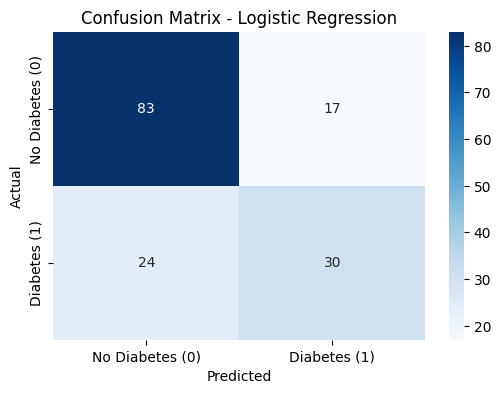

In [44]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Diabetes (0)", "Diabetes (1)"],
    yticklabels=["No Diabetes (0)", "Diabetes (1)"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [45]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["No Diabetes", "Diabetes"]
))

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.78      0.83      0.80       100
    Diabetes       0.64      0.56      0.59        54

    accuracy                           0.73       154
   macro avg       0.71      0.69      0.70       154
weighted avg       0.73      0.73      0.73       154



ROC-AUC Score: 0.841


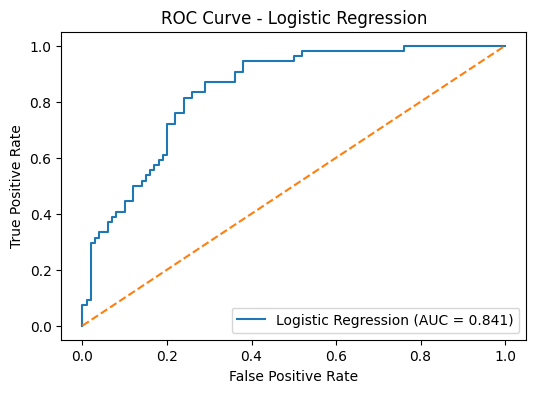

In [46]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get probability predictions
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate AUC
auc_score = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", round(auc_score, 3))

# Plot ROC curve
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

In [47]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train_scaled, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [48]:
# Make predictions using Random Forest
y_pred_rf = rf_model.predict(X_test_scaled)

print("Random Forest predictions completed successfully!")
print("First 10 predictions:", y_pred_rf[:10])

Random Forest predictions completed successfully!
First 10 predictions: [1 0 0 0 0 0 0 1 0 1]


In [49]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", round(rf_accuracy * 100, 2), "%")

Random Forest Accuracy: 76.62 %


Random Forest Confusion Matrix:
[[84 16]
 [20 34]]


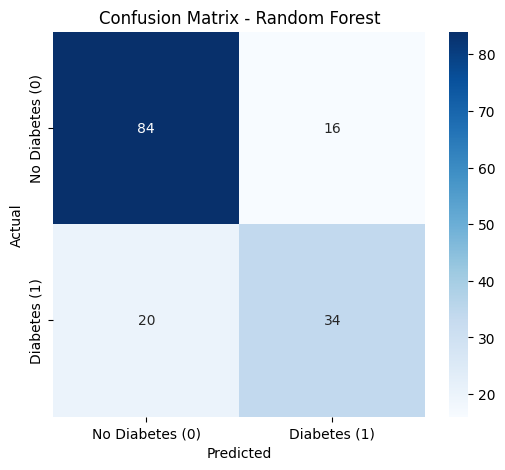

In [50]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Random Forest Confusion Matrix:")
print(cm_rf)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Diabetes (0)", "Diabetes (1)"],
    yticklabels=["No Diabetes (0)", "Diabetes (1)"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [51]:
from sklearn.metrics import classification_report

print("Random Forest Classification Report:")

print(classification_report(
    y_test,
    y_pred_rf,
    target_names=["No Diabetes", "Diabetes"]
))

Random Forest Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.81      0.84      0.82       100
    Diabetes       0.68      0.63      0.65        54

    accuracy                           0.77       154
   macro avg       0.74      0.73      0.74       154
weighted avg       0.76      0.77      0.76       154



Random Forest ROC-AUC Score: 0.827


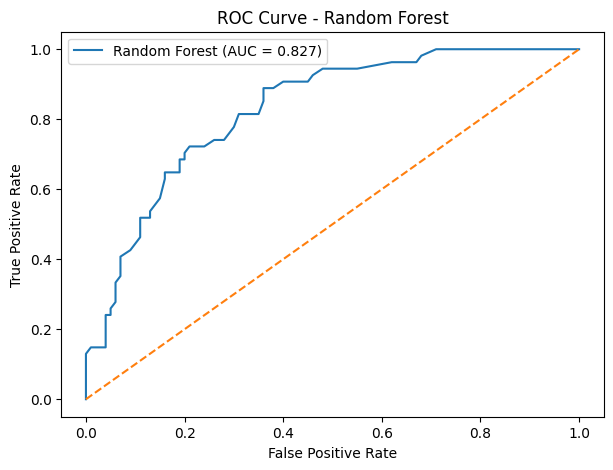

In [52]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get probability predictions
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

# Calculate ROC curve and AUC
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_prob_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest ROC-AUC Score:", round(roc_auc_rf, 3))

# Plot ROC curve
plt.figure(figsize=(7, 5))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_rf:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

In [55]:
from sklearn.metrics import roc_auc_score

# Calculate Logistic Regression ROC-AUC again
y_prob_lr = model.predict_proba(X_test_scaled)[:, 1]
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)

print("MODEL COMPARISON")
print("=" * 40)

print("Logistic Regression Accuracy:", round(accuracy * 100, 2), "%")
print("Logistic Regression ROC-AUC:", round(roc_auc_lr, 3))

print()

print("Random Forest Accuracy:", round(rf_accuracy * 100, 2), "%")
print("Random Forest ROC-AUC:", round(roc_auc_rf, 3))

MODEL COMPARISON
Logistic Regression Accuracy: 73.38 %
Logistic Regression ROC-AUC: 0.841

Random Forest Accuracy: 76.62 %
Random Forest ROC-AUC: 0.827
